# GrainTrace - Experiment

## 1. Purpose

This notebook is dedicated to test preprocessing pipelines for our GrainTrace project

Preprocessing steps:
1. BG removal using transparent-background tool based on deep neural network segmentation models
2. Black BG
3. Grayscale



# Tools installation

### Transparent-background

In [ ]:
!pip install transparent-background

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 115.5 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=1db77a700f25133e760da3a389b8df386ec7b5c8dd4170a8f12a19a05d8a6e40
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


# Imports

In [ ]:
# from rembg import remove
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from transparent_background import Remover

ModuleNotFoundError: No module named 'transparent_background'

# Bg removal tests

### Transparent-background

Settings -> Mode=base, Device=cuda:0, Torchscript=disabled


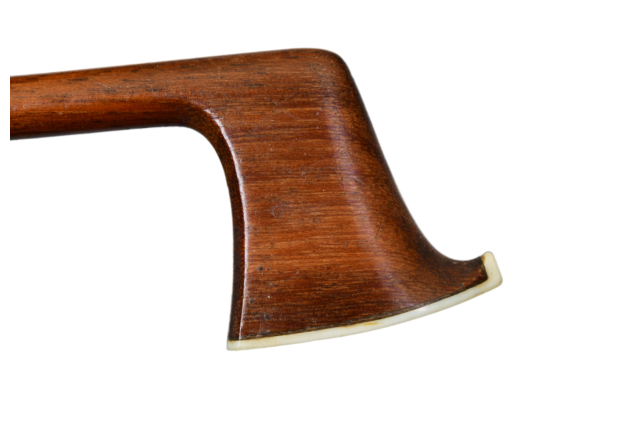

In [ ]:
remover = Remover(mode='base')  # uses GPU automatically if torch detects CUDA

image_path = "/content/0001_RSU_F_JPEG.JPG"
img = Image.open(image_path).convert("RGB")

out = remover.process(img, type='rgba')  # RGBA = transparent background



plt.figure(figsize=(8, 8))
plt.imshow(out)
plt.axis("off")
plt.show()

# Models usually takes 3 channels as input so blacken the bg and convert to rgb

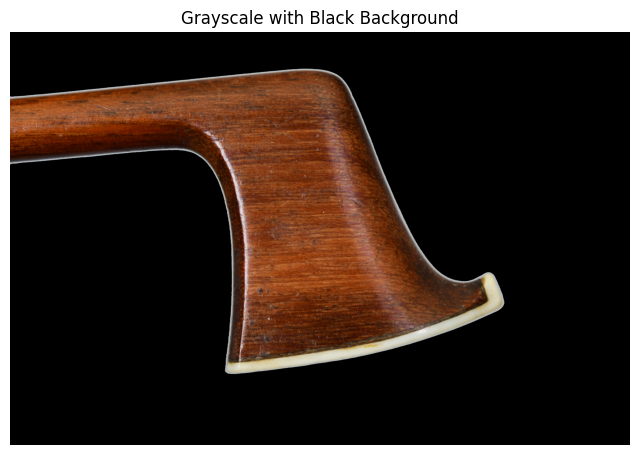

In [ ]:
rgba = np.array(out)

# Alpha channel is the segmentation mask
alpha = rgba[:, :, 3]

# Convert original to BGR
roi = cv2.imread(image_path)

# Make background black
segmented = cv2.bitwise_and(roi, roi, mask=alpha)
segmented_rgb = cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(8, 8))
plt.imshow(segmented_rgb)
plt.title("RGB with Black Background")
plt.axis("off")
plt.show()



# GrayScale

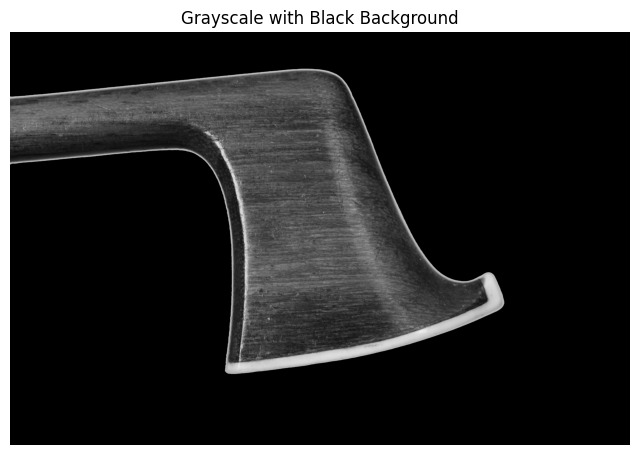

In [ ]:
gray_segmented = cv2.cvtColor(segmented, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 8))
plt.imshow(gray_segmented, cmap="gray")
plt.title("Grayscale with Black Background")
plt.axis("off")
plt.show()

api.py

In [ ]:
from functools import lru_cache

from fastapi import APIRouter, File, UploadFile
from fastapi.responses import Response

from app.pipeline import ImagePreprocessingPipeline

router = APIRouter()


@lru_cache(maxsize=1)     # load model once, reuse across requests, if needed
def get_pipeline() -> ImagePreprocessingPipeline:     # on idle bad, for multible pictures good
    return ImagePreprocessingPipeline()


@router.post("/preprocess")
async def pipeline(file: UploadFile = File(...)):
    content = await file.read()
    result = get_pipeline().run(content)
    return Response(content=result, media_type="image/jpeg")


# @router.post("/preprocess")
# async def pipeline(file: UploadFile = File(...)):
#     content = await file.read()
#     result = ImagePreprocessingPipeline().run(content)
#     return Response(content=result, media_type="image/jpeg")

pipeline.py

In [ ]:
import io
import cv2
import numpy as np
from PIL import Image
from transparent_background import Remover


class ImagePreprocessingPipeline:

    def __init__(self, mode: str = "base"):
        self.remover = Remover(mode=mode)

    def run(self, image_bytes: bytes) -> bytes:
        # step 1: bg removal -> rgba
        img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        out = self.remover.process(img, type="rgba")

        # step 2: black background via alpha mask on original
        rgba = np.array(out)
        alpha = rgba[:, :, 3]     # mask
        roi = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)      # rgb -> bgr
        segmented = cv2.bitwise_and(roi, roi, mask=alpha)

        # step 3: grayscale
        gray = cv2.cvtColor(segmented, cv2.COLOR_BGR2GRAY)

        _, buf = cv2.imencode(".jpg", gray)
        return buf.tobytes()